In [18]:
import pandas as pd
import numpy as np
import seaborn as sns 
import matplotlib.pyplot as plt

In [19]:
df=pd.read_csv('insurance.csv')
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [20]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [21]:
df.shape


(1338, 7)

In [22]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [23]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [24]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


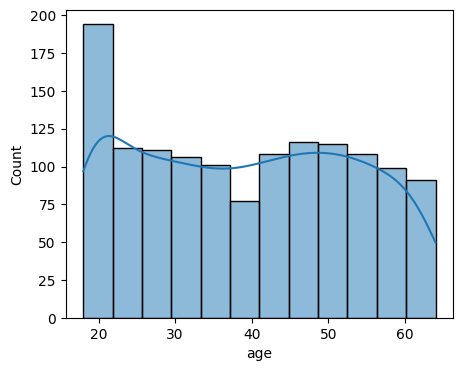

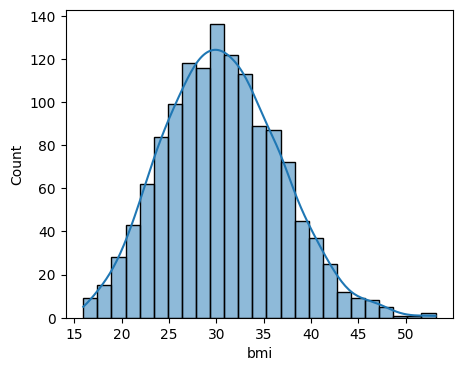

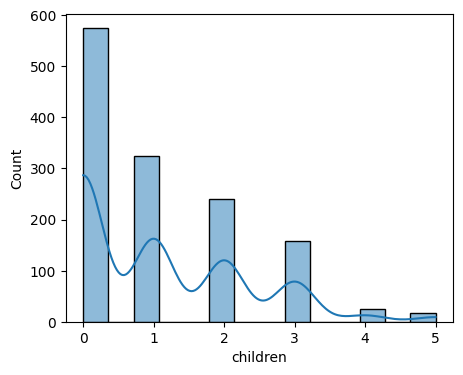

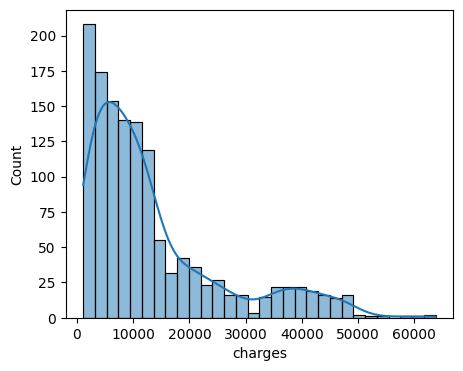

In [25]:
numeric_columns=['age','bmi','children','charges']
for col in numeric_columns:
    plt.figure(figsize=(5,4))
    sns.histplot(df[col],kde=True)

<Axes: xlabel='children', ylabel='count'>

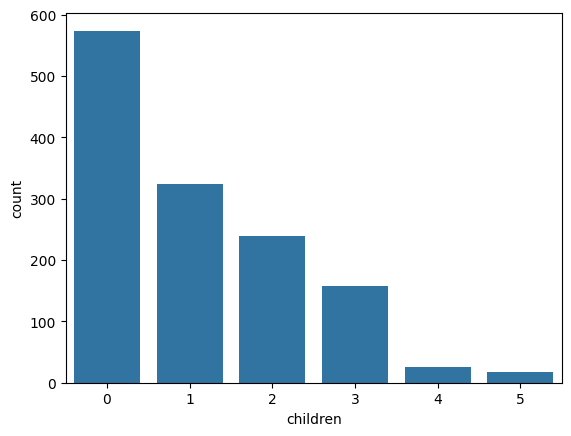

In [26]:
sns.countplot(x=df['children'])

<Axes: xlabel='sex', ylabel='count'>

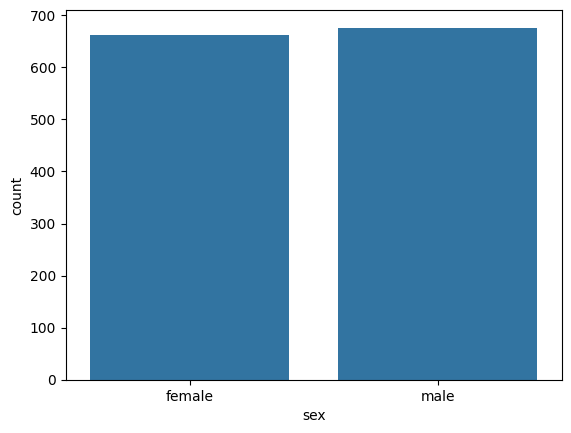

In [27]:
sns.countplot(x=df['sex'])

<Axes: xlabel='smoker', ylabel='count'>

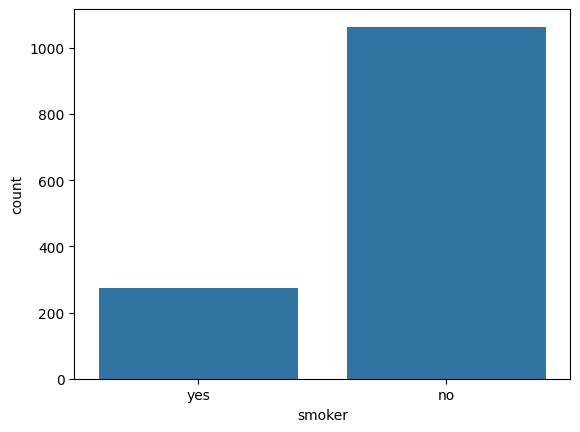

In [28]:
sns.countplot(x=df['smoker'])

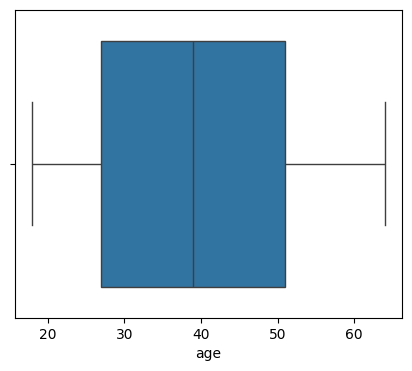

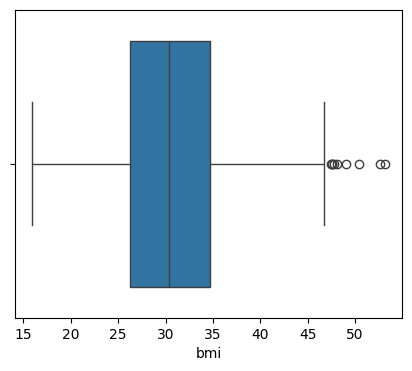

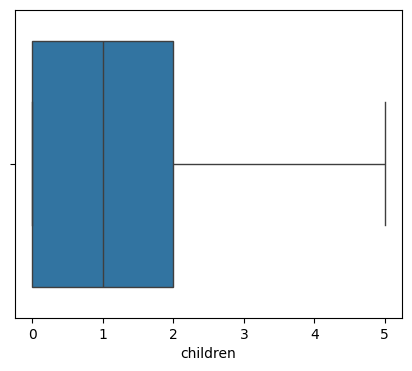

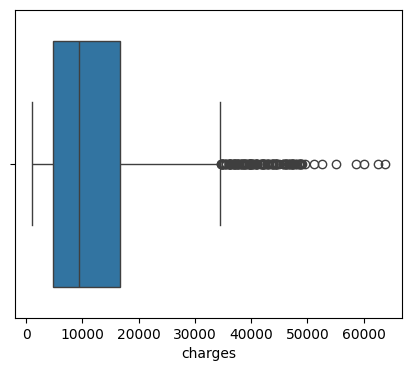

In [29]:
for col in numeric_columns:
    plt.figure(figsize=(5,4))
    sns.boxplot(x=df[col])

<Axes: >

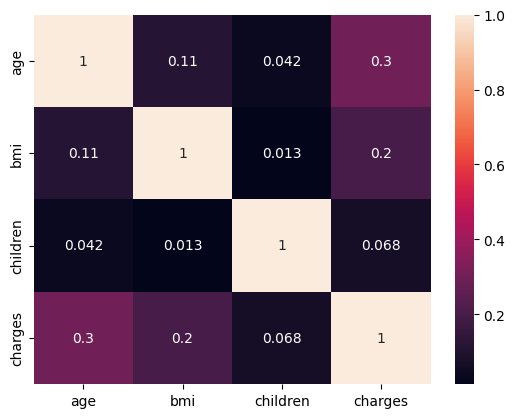

In [30]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

In [31]:
cleaned_df=df.copy()

In [32]:
cleaned_df.drop_duplicates(inplace=True)


In [33]:
cleaned_df['sex'].value_counts

<bound method IndexOpsMixin.value_counts of 0       female
1         male
2         male
3         male
4         male
         ...  
1333      male
1334    female
1335    female
1336    female
1337    female
Name: sex, Length: 1337, dtype: str>

In [34]:
cleaned_df['sex']=cleaned_df['sex'].map({'male':0,'female':1})


In [35]:
cleaned_df['smoker']=cleaned_df['smoker'].map({'yes':1,'no':0})
cleaned_df.head()


,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520


In [36]:
cleaned_df=pd.get_dummies(cleaned_df,columns=['region'],drop_first=True)

In [37]:
cleaned_df['bmi_categories']=pd.cut(
    cleaned_df['bmi'],
    bins=[0,18.5,25,30,float('inf')],
    labels=['underweight','normal_weight','overweight','obesity']
)
cleaned_df

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest,bmi_categories
0,19,1,27.900,0,1,16884.92400,False,False,True,overweight
1,18,0,33.770,1,0,1725.55230,False,True,False,obesity
2,28,0,33.000,3,0,4449.46200,False,True,False,obesity
3,33,0,22.705,0,0,21984.47061,True,False,False,normal_weight
4,32,0,28.880,0,0,3866.85520,True,False,False,overweight
...,...,...,...,...,...,...,...,...,...,...
1333,50,0,30.970,3,0,10600.54830,True,False,False,obesity
1334,18,1,31.920,0,0,2205.98080,False,False,False,obesity
1335,18,1,36.850,0,0,1629.83350,False,True,False,obesity
1336,21,1,25.800,0,0,2007.94500,False,False,True,overweight


In [38]:
cleaned_df=pd.get_dummies(cleaned_df,columns=['bmi_categories'])
cleaned_df=cleaned_df.astype(int)
cleaned_df

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest,bmi_categories_underweight,bmi_categories_normal_weight,bmi_categories_overweight,bmi_categories_obesity
0,19,1,27,0,1,16884,0,0,1,0,0,1,0
1,18,0,33,1,0,1725,0,1,0,0,0,0,1
2,28,0,33,3,0,4449,0,1,0,0,0,0,1
3,33,0,22,0,0,21984,1,0,0,0,1,0,0
4,32,0,28,0,0,3866,1,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1333,50,0,30,3,0,10600,1,0,0,0,0,0,1
1334,18,1,31,0,0,2205,0,0,0,0,0,0,1
1335,18,1,36,0,0,1629,0,1,0,0,0,0,1
1336,21,1,25,0,0,2007,0,0,1,0,0,1,0


In [39]:
from sklearn.preprocessing import StandardScaler
col=['bmi','age','children']
scaler=StandardScaler()
cleaned_df[col]=scaler.fit_transform(cleaned_df[col])
cleaned_df.head()

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest,bmi_categories_underweight,bmi_categories_normal_weight,bmi_categories_overweight,bmi_categories_obesity
0,-1.440418,1,-0.517949,-0.909234,1,16884,0,0,1,0,0,1,0
1,-1.511647,0,0.462463,-0.079442,0,1725,0,1,0,0,0,0,1
2,-0.799350,0,0.462463,1.580143,0,4449,0,1,0,0,0,0,1
3,-0.443201,0,-1.334960,-0.909234,0,21984,1,0,0,0,1,0,0
4,-0.514431,0,-0.354547,-0.909234,0,3866,1,0,0,0,0,1,0


In [40]:
selected_features={
    'age', 'sex', 'bmi', 'children', 'smoker', 'charges',
       'region_northwest', 'region_southeast', 'region_southwest',
       'bmi_categories_underweight', 'bmi_categories_normal_weight',
       'bmi_categories_overweight', 'bmi_categories_obesity'
}

In [41]:
from scipy.stats import pearsonr


In [42]:
corelation={
feature:pearsonr(cleaned_df[feature],cleaned_df['charges'])[0]
    for feature in selected_features
}
pearson_correlation=pd.DataFrame(list(corelation.items()),columns=['features','correlation'])
pearson_correlation.sort_values(by='correlation',ascending=False)

,features,correlation
11,charges,1.000000
9,smoker,0.787234
7,age,0.298309
10,bmi_categories_obesity,0.200502
3,bmi,0.196236
6,region_southeast,0.073577
1,children,0.067390
8,region_northwest,-0.038695
5,region_southwest,-0.043637
2,bmi_categories_underweight,-0.048225


In [43]:
cat_features={
    'bmi_categories_obesity',
    'region_southeast',
    'region_northwest',
    'region_southwest',
    'bmi_categories_underweight',
    'bmi_categories_normal_weight',
    'bmi_categories_overweight',
    'sex',
    'smoker'
}

In [44]:
from scipy.stats import chi2_contingency

# bin charges first since it's continuous
cleaned_df['charges_binned'] = pd.qcut(cleaned_df['charges'], q=4,
                               labels=['low', 'medium', 'high', 'very_high'])

results = {}
for feature in cat_features:
    table = pd.crosstab(cleaned_df[feature], cleaned_df['charges_binned'])
    chi2, p, dof, _ = chi2_contingency(table)
    results[feature] = {'Chi2 Score': round(chi2, 2), 'P-Value': round(p, 5)}

chi_df = pd.DataFrame(results).T.reset_index()
chi_df.columns = ['Feature', 'Chi2 Score', 'P-Value']

# decision column
chi_df['Decision'] = chi_df['P-Value'].apply(
    lambda x: '✅ Keep' if x < 0.05 else '❌ Dump'
)

chi_df.sort_values(by='Chi2 Score', ascending=False)

,Feature,Chi2 Score,P-Value,Decision
6,smoker,848.22,0.00000,✅ Keep
4,region_southeast,16.00,0.00113,✅ Keep
0,sex,10.26,0.01649,✅ Keep
7,bmi_categories_obesity,8.55,0.03585,✅ Keep
3,region_southwest,5.09,0.16519,❌ Dump
1,bmi_categories_underweight,4.38,0.22280,❌ Dump
2,bmi_categories_overweight,4.18,0.24222,❌ Dump
8,bmi_categories_normal_weight,3.61,0.30733,❌ Dump
5,region_northwest,1.13,0.76882,❌ Dump


In [45]:
final_df=cleaned_df[['age', 'sex', 'bmi', 'children', 'smoker', 'charges', 'region_southeast', 'bmi_categories_obesity']]

In [46]:
final_df

,age,sex,bmi,children,smoker,charges,region_southeast,bmi_categories_obesity
0,-1.440418,1,-0.517949,-0.909234,1,16884,0,0
1,-1.511647,0,0.462463,-0.079442,0,1725,1,1
2,-0.799350,0,0.462463,1.580143,0,4449,1,1
3,-0.443201,0,-1.334960,-0.909234,0,21984,0,0
4,-0.514431,0,-0.354547,-0.909234,0,3866,0,0
...,...,...,...,...,...,...,...,...
1333,0.767704,0,-0.027743,1.580143,0,10600,0,1
1334,-1.511647,1,0.135659,-0.909234,0,2205,0,1
1335,-1.511647,1,0.952670,-0.909234,0,1629,1,1
1336,-1.297958,1,-0.844753,-0.909234,0,2007,0,0


In [52]:
from sklearn.model_selection import train_test_split

In [55]:
X=final_df.drop('charges',axis=1)
y=final_df['charges']

In [56]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

In [58]:
from sklearn.linear_model import LinearRegression

In [59]:
model=LinearRegression()

In [60]:
model.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [69]:
y_pred=model.predict(X_test)
y_pred

array([ 7869.88850418,  5348.9891266 , 14616.52683432, 32510.78324286,
        8957.56451281, 13343.87604239, 30219.80453986,  1392.95749279,
       11211.70120237,  9976.4905748 , 10826.22588395, 32128.54076409,
       31608.22333147, 16176.53293383, 10278.23383007,  8449.75471359,
        5536.61089056, 32503.84413048,  3308.13799247,  3820.40012903,
        4796.81234256, 28772.20960271, 13826.60790913, 29517.34284223,
       31552.64434702,  6378.50584148, 35010.06735145, 37945.0874509 ,
       12546.39414589, 14259.83823328,  7626.85774112, 13059.0289137 ,
         521.02514322, 11309.33038195, 37515.56591166, 13381.10126892,
        3651.90025927,  4557.21455288, 31518.63715603,  7958.3339121 ,
        6067.36128263, 30428.46777261, 35308.9381064 , 13151.83312469,
        7998.03362176,  2967.71187932,  5158.33820411,  7564.55458211,
        3500.93675452, 10437.65903981,  7850.28406499, 10482.9543665 ,
       30317.68243495,  4736.52001334, 11703.12200386, 11510.57195732,
      

In [70]:
from sklearn.metrics import r2_score

In [71]:
r2_score(y_test,y_pred)

0.8039290681086955